# Project Work XAI

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp//tmux-1022/default,842946,2


In [3]:
import os
print(os.getpid())

1509078


In [4]:
import os
print("Il mio PID:", os.getpid())
print("Il PID del processo Padre (chi mi ha avviato):", os.getppid())

Il mio PID: 1509078
Il PID del processo Padre (chi mi ha avviato): 1488280


In [5]:
!nvidia-smi

Sat May 23 12:13:55 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2070 ...    Off | 00000000:04:00.0 Off |                  N/A |
| 38%   30C    P8              11W / 215W |     19MiB /  8192MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [6]:
import os
import torch

print("=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===")

# Verifica cosa ha ereditato dal terminale
cuda_vis = os.environ.get("CUDA_VISIBLE_DEVICES")
print(f"1. Variabile CUDA_VISIBLE_DEVICES ereditata: {cuda_vis}")

print(f"\n2. PYTORCH:")
print(f"   - Quante GPU vede all'interno del suo recinto: {torch.cuda.device_count()}")

cuda_available = torch.cuda.is_available()
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0) # Usa sempre 0, perché è l'unica che vede!
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   - Modello agganciato: {gpu_name}")
    print(f"   - Total VRAM memory: {total_memory:.2f} GB")
else:
    print("   - WARNING: PyTorch sta usando la CPU.")

# Test di allocazione
device = torch.device("cuda" if cuda_available else "cpu")
x = torch.randn(1000, 1000).to(device)
print(f"\nTest tensore allocato su: {x.device}")

=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===
1. Variabile CUDA_VISIBLE_DEVICES ereditata: 0

2. PYTORCH:
   - Quante GPU vede all'interno del suo recinto: 1
   - Modello agganciato: NVIDIA GeForce RTX 2080 SUPER
   - Total VRAM memory: 8.36 GB

Test tensore allocato su: cuda:0


In [7]:
device = torch.device("cuda" if cuda_available else "cpu")
print(f"Device: {device}") # now it works

Device: cuda


## Environment management

In [8]:
import os
import sys

# detecting environment
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# setting filesystem and paths
if is_colab():
    print("Running in Google Colab detected.")
    # cloning repository
    repo_url = "https://github.com/Epot12/Lab_XAI.git"
    repo_name = "Lab_XAI"

    # cloning only if it hasn't already been done in this session
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # changing the working directory to the project directory
    os.chdir(repo_name)

    # Adding the folder to the system paths
    sys.path.append(os.getcwd())
    print(f"Working directory set to: {os.getcwd()}")

else:
    from pathlib import Path
    print("Local execution detected.")
    def project_root():
        current = Path.cwd().resolve()
        for path in [current] + list(current.parents):
            if (path / ".git").exists():
                return path
        raise RuntimeError("Project root not found")

    os.chdir(project_root())
    sys.path.append(str(project_root()))
    print(f"Working directory set to: {os.getcwd()}")

Local execution detected.
Working directory set to: /home/emiliano/projects/project_1/Lab_XAI


In [9]:
# installing uv

if is_colab():
    print("Installing uv...")
    !curl -LsSf https://astral.sh/uv/install.sh | sh

    # Reload the path to show the UV track

    os.environ['PATH'] += ':/root/.cargo/bin'

    print("Environment synchronization...")
    # Synchronize Colab's system environment with local environment dependencies
    !uv pip install --system -r pyproject.toml

In [10]:
modules_folder = os.path.abspath("Lab_XAI_pytorch")
if modules_folder not in sys.path:
    sys.path.append(modules_folder)

import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from k_validation.K_fold import *
from models.neural_network import *
from utils.data_processing import *
from utils.pipeline import pipeline

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [11]:
X, y, feature_names = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

### Experiment 1: batch_size = 32

=== Starting Experiment Pipeline: exp_1 ===
Created isolated environment at: experiments/exp_1_20260521_160615

--- Starting FOLD 0 ---


Early stopping at epoch 15
Train MSE: 7.695, Test MSE: 11.440, Train MAE: 2.111, Test MAE: 2.385

--- Starting FOLD 1 ---


Early stopping at epoch 11
Train MSE: 8.751, Test MSE: 10.048, Train MAE: 2.314, Test MAE: 2.470

--- Starting FOLD 2 ---


Early stopping at epoch 14
Train MSE: 7.582, Test MSE: 9.954, Train MAE: 2.076, Test MAE: 2.488

--- Starting FOLD 3 ---


Early stopping at epoch 16
Train MSE: 7.432, Test MSE: 15.012, Train MAE: 2.040, Test MAE: 2.945

--- Starting FOLD 4 ---


...

Early stopping at epoch 12
Train MSE: 7.703, Test MSE: 49.673, Train MAE: 2.128, Test MAE: 5.191

--- Starting FOLD 6 ---


Early stopping at epoch 16
Train MSE: 7.471, Test MSE: 38.488, Train MAE: 2.084, Test MAE: 4.554

--- Starting FOLD 7 ---


Early stopping at epoch 16
Train MSE: 7.750, Test MSE: 21.334, Train MAE: 2.149, Test MAE: 3.430

--- Starting FOLD 8 ---


Early stopping at epoch 14
Train MSE: 7.971, Test MSE: 10.647, Train MAE: 2.157, Test MAE: 2.558

--- Starting FOLD 9 ---


Early stopping at epoch 22
Train MSE: 7.530, Test MSE: 11.335, Train MAE: 2.099, Test MAE: 2.490

Execution 'exp_1' successfully completed in 13923.08s!
Generating Learning Curves...


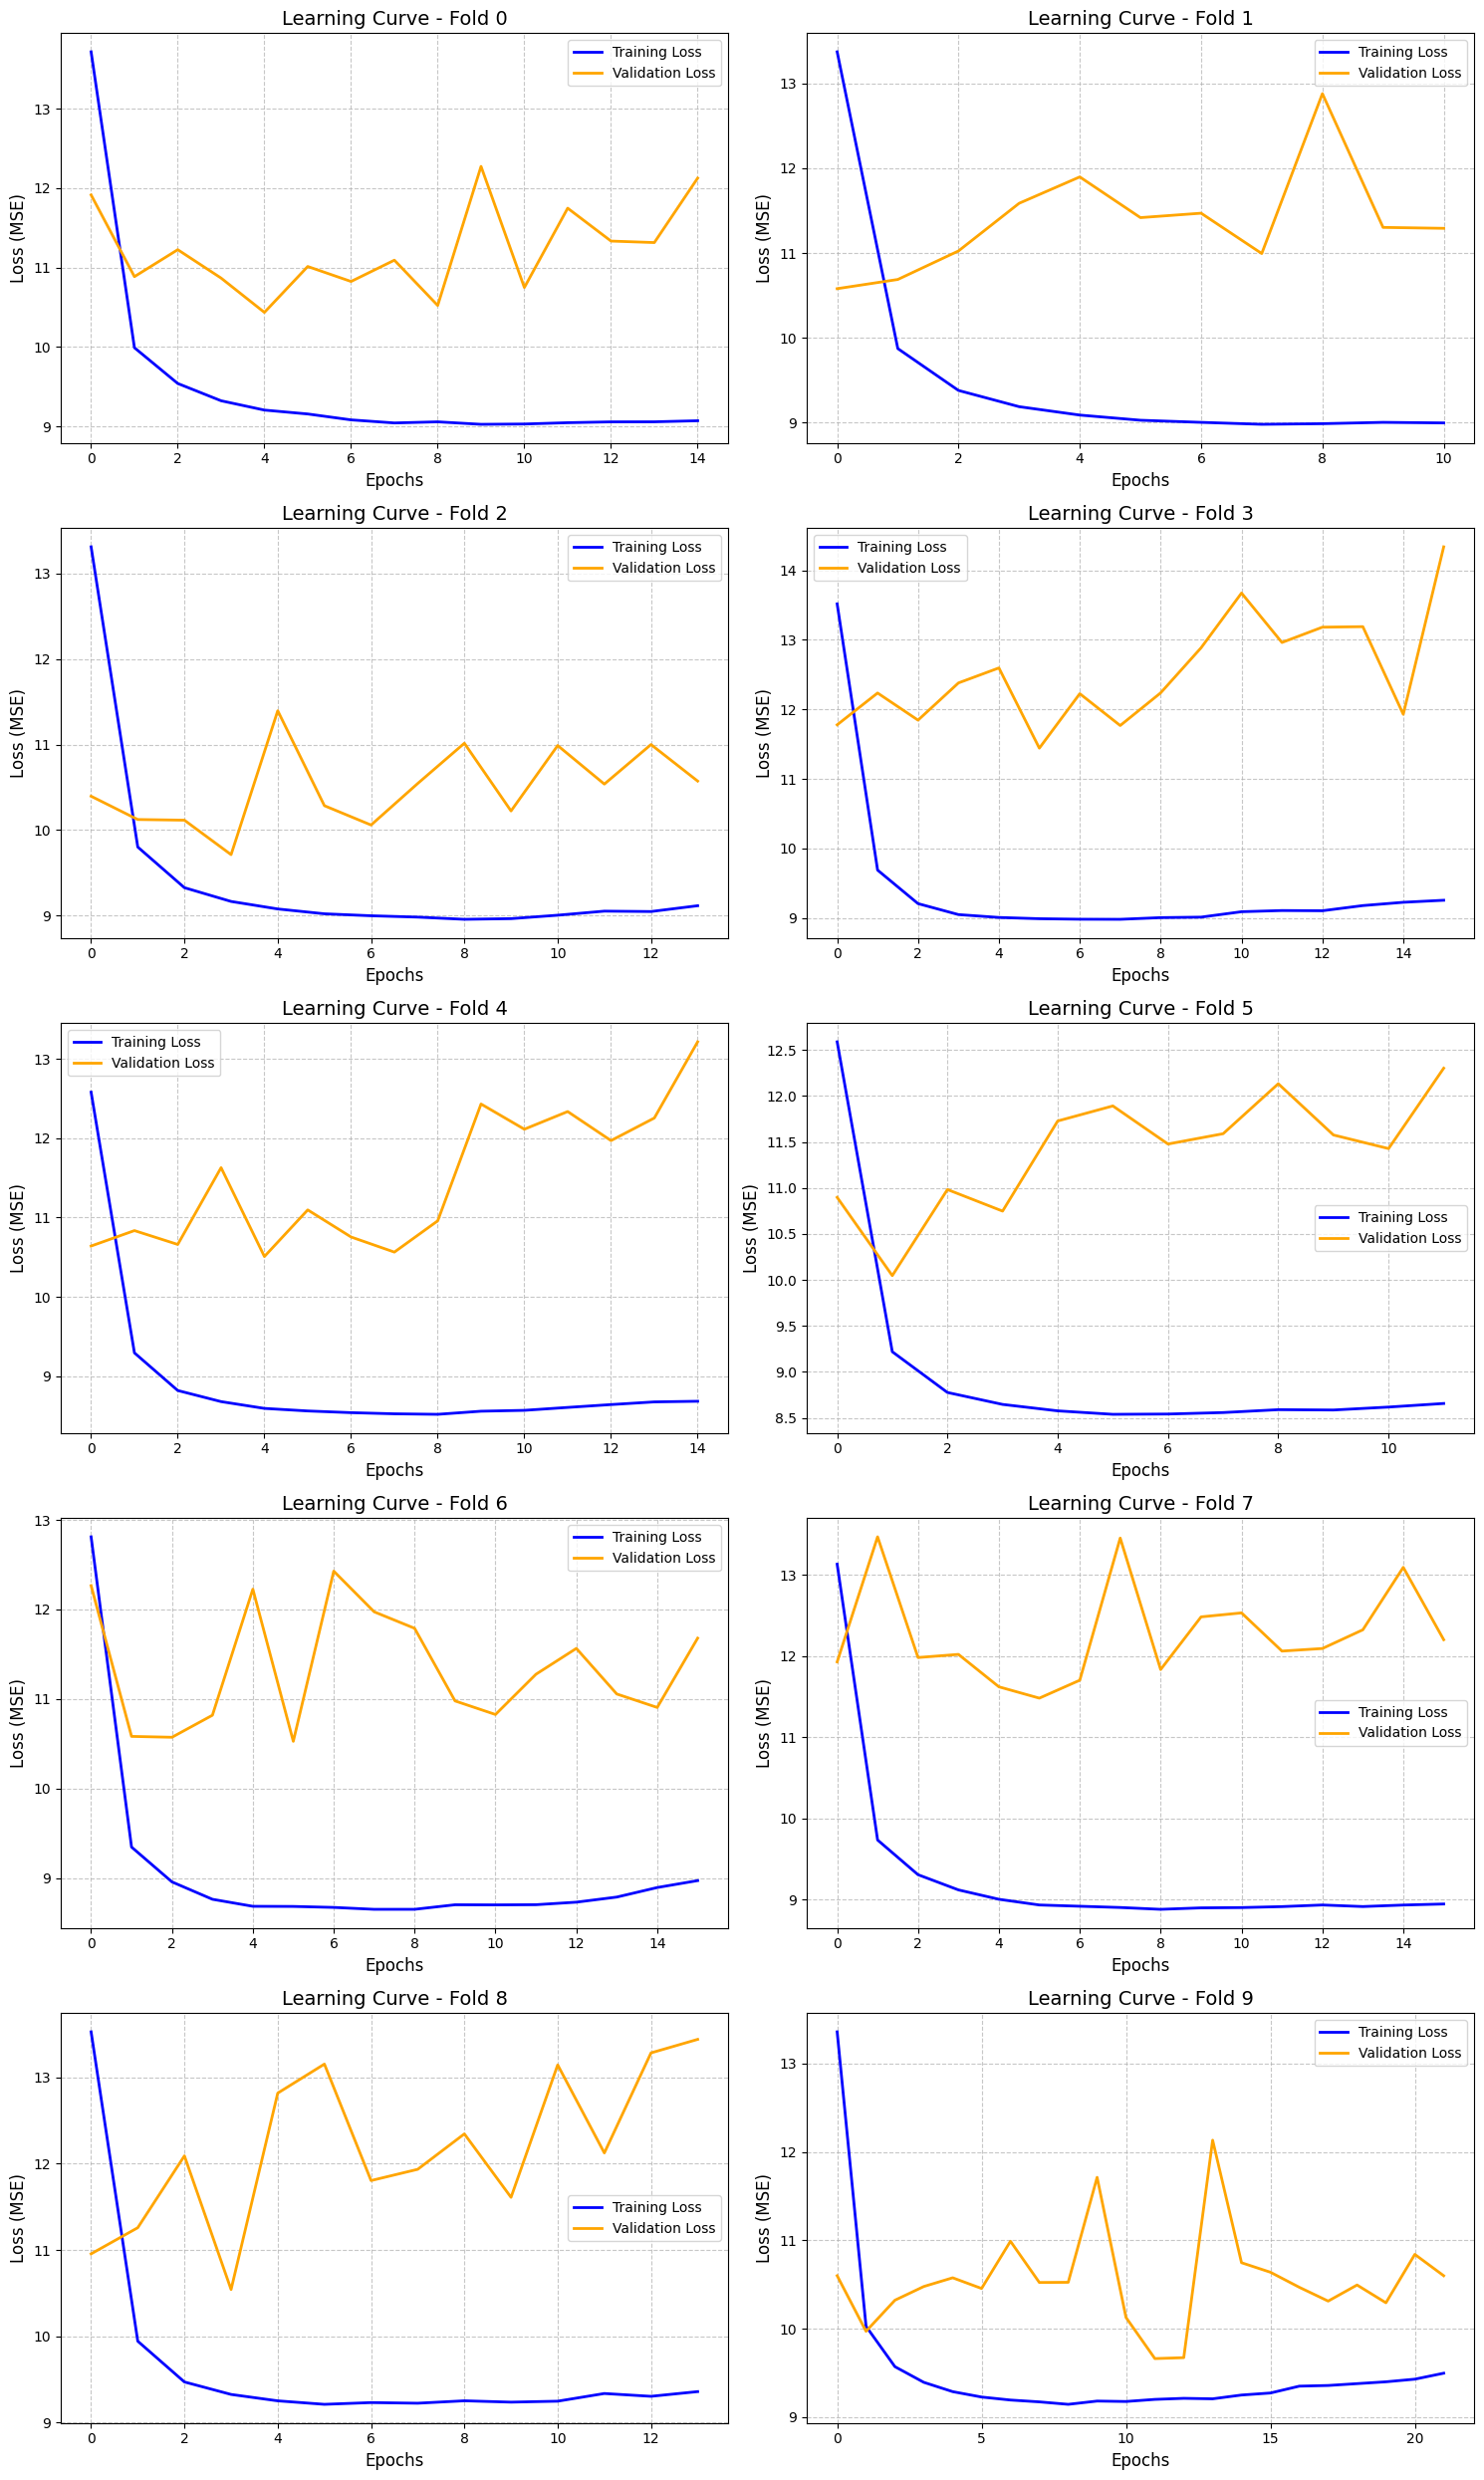

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_1_20260521_160615


In [12]:
k_fold_dict_1, save_dir_1 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_1")

### Experiment 2: batch_size = 256

=== Starting Experiment Pipeline: exp_2 ===
Created isolated environment at: experiments/exp_2_20260521_203007

--- Starting FOLD 0 ---


Early stopping at epoch 19
Train MSE: 7.700, Test MSE: 11.421, Train MAE: 2.147, Test MAE: 2.630

--- Starting FOLD 1 ---


Early stopping at epoch 15
Train MSE: 7.599, Test MSE: 10.075, Train MAE: 2.116, Test MAE: 2.494

--- Starting FOLD 2 ---


Early stopping at epoch 18
Train MSE: 7.033, Test MSE: 11.089, Train MAE: 2.024, Test MAE: 2.638

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 8.173, Test MSE: 12.840, Train MAE: 2.200, Test MAE: 2.748

--- Starting FOLD 4 ---


...

Early stopping at epoch 13
Train MSE: 7.752, Test MSE: 47.549, Train MAE: 2.115, Test MAE: 5.218

--- Starting FOLD 6 ---


Early stopping at epoch 15
Train MSE: 7.693, Test MSE: 36.319, Train MAE: 2.136, Test MAE: 4.439

--- Starting FOLD 7 ---


Early stopping at epoch 17
Train MSE: 7.459, Test MSE: 21.738, Train MAE: 2.115, Test MAE: 3.576

--- Starting FOLD 8 ---


Early stopping at epoch 15
Train MSE: 8.762, Test MSE: 13.136, Train MAE: 2.345, Test MAE: 3.011

--- Starting FOLD 9 ---


Early stopping at epoch 12
Train MSE: 7.973, Test MSE: 11.121, Train MAE: 2.133, Test MAE: 2.457

Execution 'exp_2' successfully completed in 2734.59s!
Generating Learning Curves...


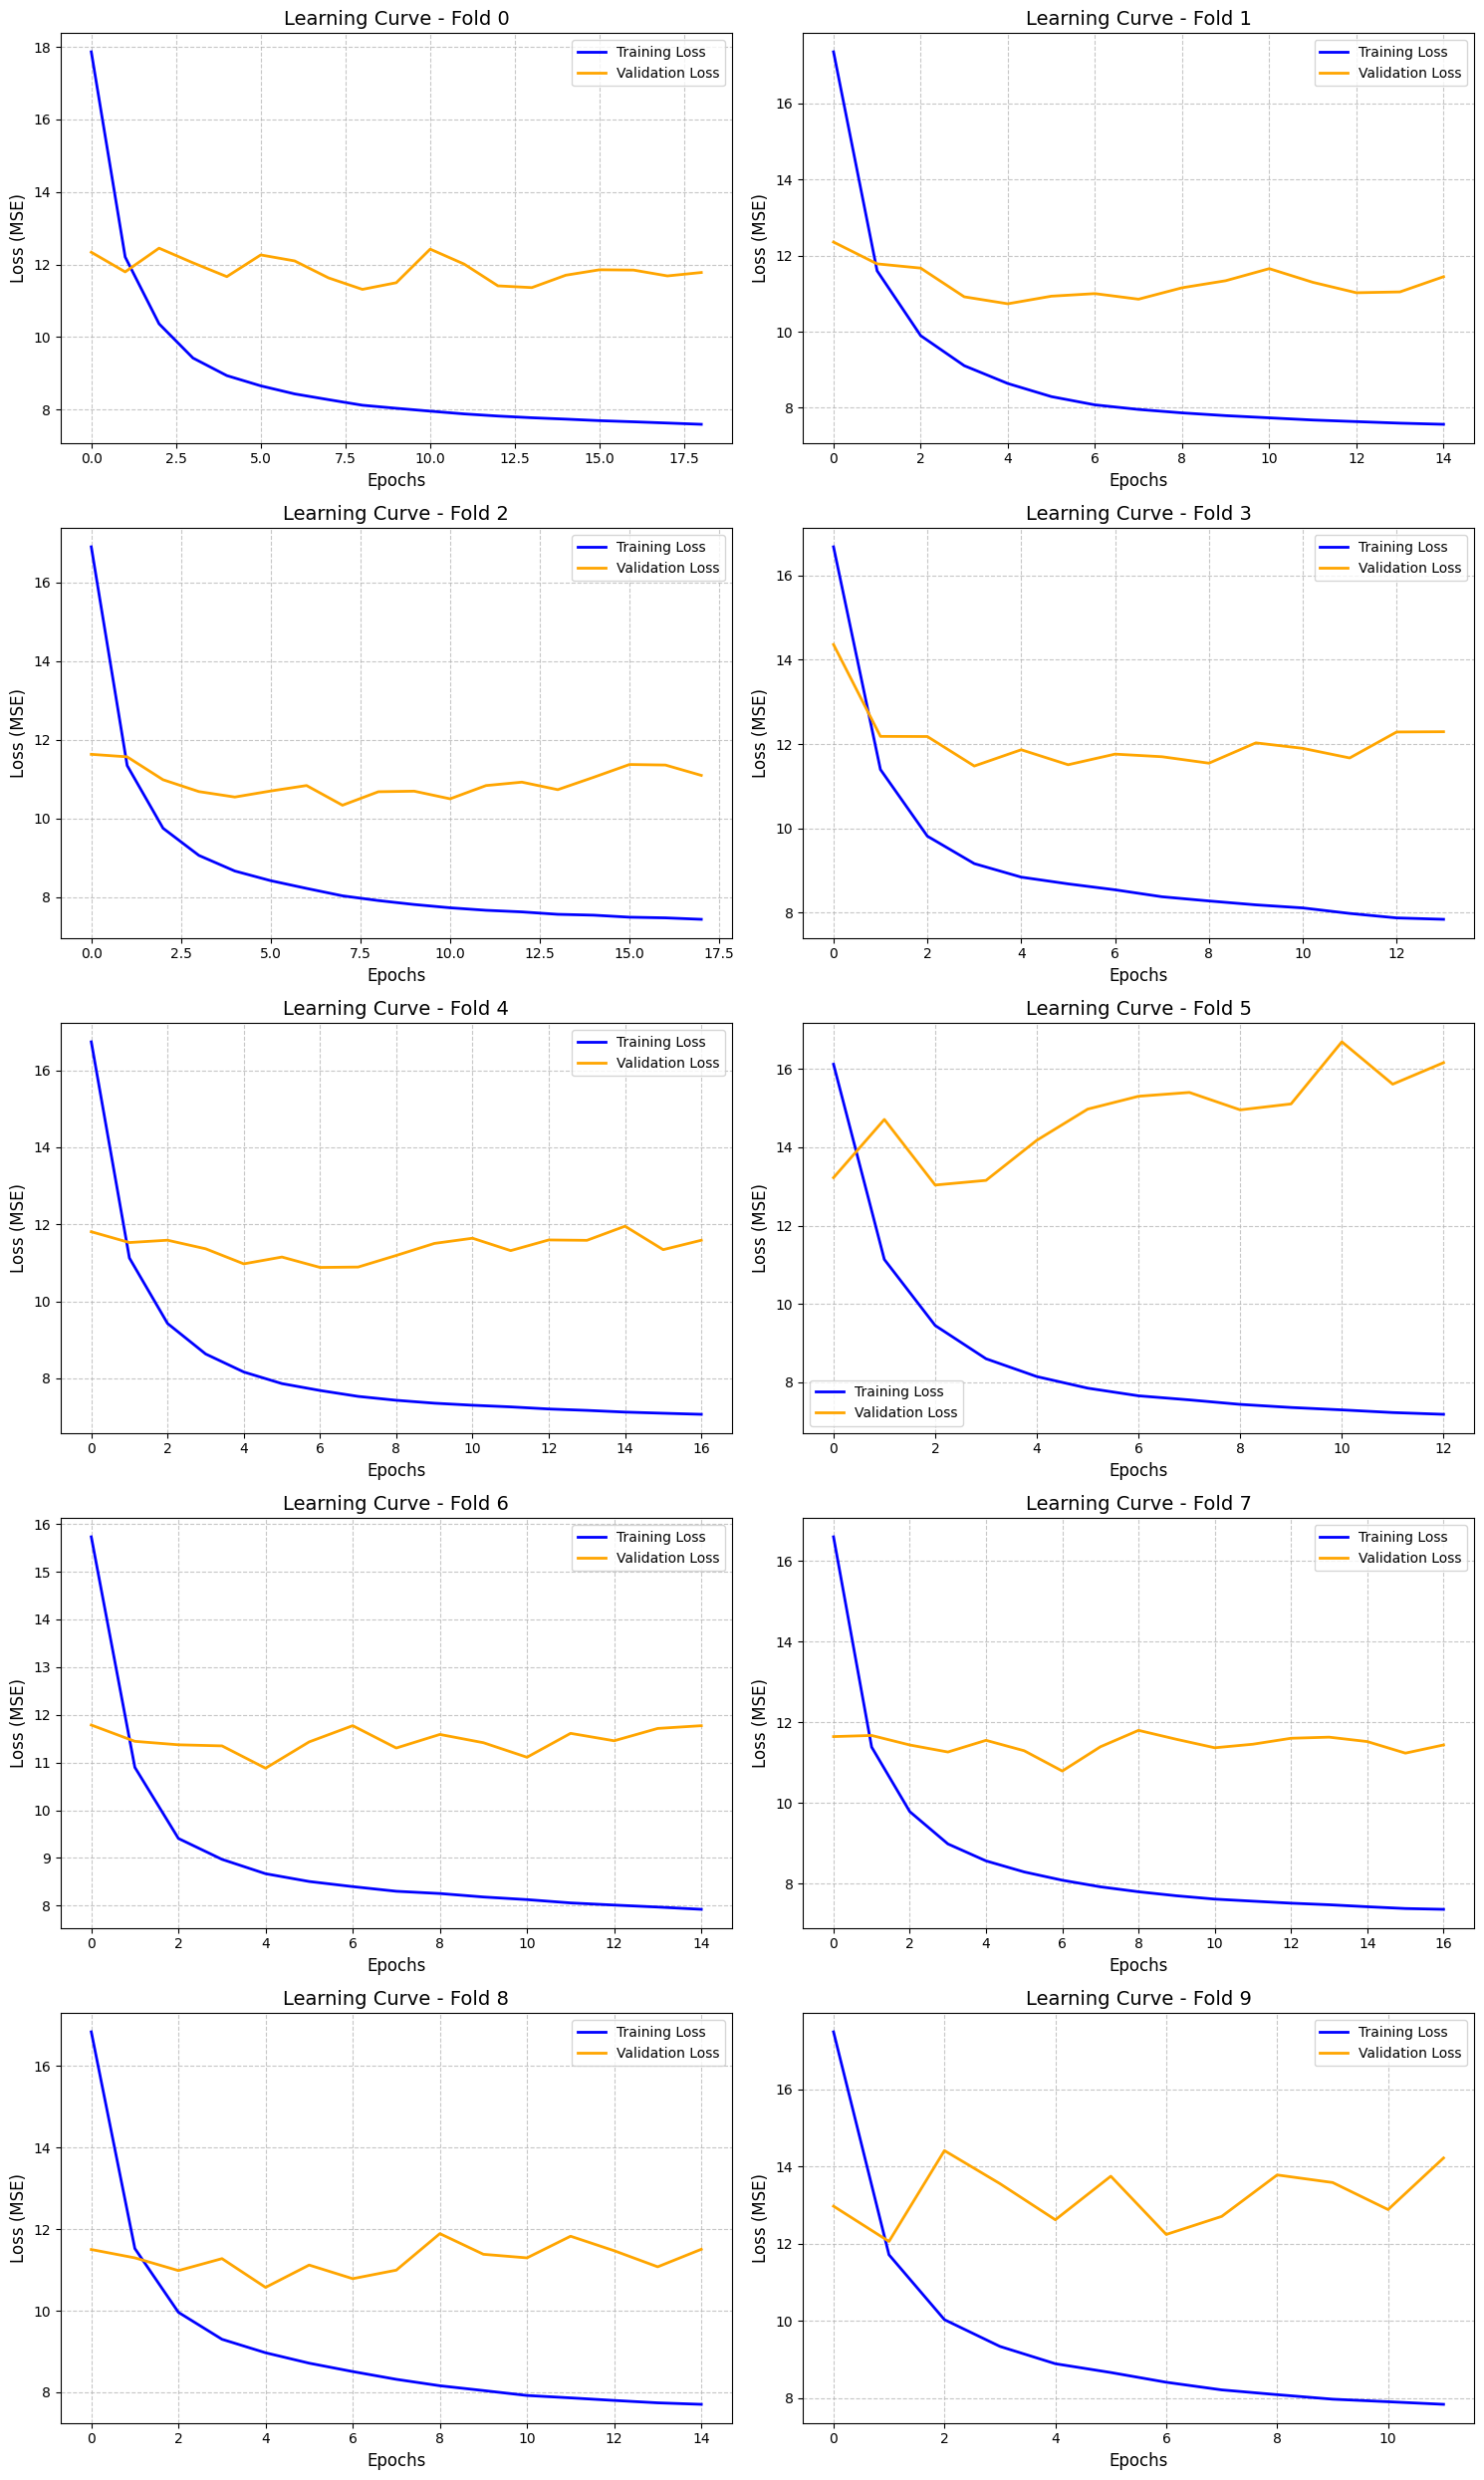

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_2_20260521_203007


In [12]:
k_fold_dict_2, save_dir_2 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_2")

In [12]:
print(k_fold_dict_2)

{'MAE': 3.370018347040911, 'MAPE': 0.25563652946529525, 'MSE': 21.30989163630756, 'predictions': array([12.59172058, 12.59132671, 12.59096813, ..., 11.67141724,
       11.66817188, 11.66492653], shape=(1905841,)), 'execution_time': 1914.3073630332947, 'histories': [{'train_loss': [np.float64(19.6568941647013), np.float64(12.013114592464108), np.float64(9.942472551181687), np.float64(8.96185637540316), np.float64(8.470467870734735), np.float64(8.195428006231163), np.float64(8.027416511033428), np.float64(7.923415067322), np.float64(7.843182303185606), np.float64(7.7853362569364615), np.float64(7.726424845311401)], 'val_loss': [12.658727645874023, 16.161497116088867, 14.178004264831543, 14.40145492553711, 14.3273344039917, 13.14233684539795, 13.764396667480469, 12.981348991394043, 13.274319648742676, 14.384540557861328, 14.998696327209473]}, {'train_loss': [np.float64(19.05168944048735), np.float64(11.796182740922593), np.float64(9.821664746691983), np.float64(8.822877163081358), np.floa

### Experiment 3: batch_size = 32 no flux

In [ ]:
X_3, y_3, feature_names_3 = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=False)

=== Starting Experiment Pipeline: exp_3 ===
Created isolated environment at: experiments/exp_3_20260520_195537

--- Starting FOLD 0 ---


Early stopping at epoch 15
Train MSE: 7.846, Test MSE: 13.905, Train MAE: 2.142, Test MAE: 2.798

--- Starting FOLD 1 ---


Early stopping at epoch 18
Train MSE: 7.556, Test MSE: 9.821, Train MAE: 2.080, Test MAE: 2.439

--- Starting FOLD 2 ---


Early stopping at epoch 19
Train MSE: 7.426, Test MSE: 11.135, Train MAE: 2.055, Test MAE: 2.652

--- Starting FOLD 3 ---


Early stopping at epoch 14
Train MSE: 7.656, Test MSE: 14.076, Train MAE: 2.082, Test MAE: 2.848

--- Starting FOLD 4 ---


...

Early stopping at epoch 14
Train MSE: 7.426, Test MSE: 46.958, Train MAE: 2.077, Test MAE: 4.990

--- Starting FOLD 6 ---


Early stopping at epoch 17
Train MSE: 7.582, Test MSE: 37.165, Train MAE: 2.100, Test MAE: 4.415

--- Starting FOLD 7 ---


Early stopping at epoch 11
Train MSE: 8.635, Test MSE: 19.927, Train MAE: 2.283, Test MAE: 3.361

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 9.230, Test MSE: 25.673, Train MAE: 2.392, Test MAE: 3.725

--- Starting FOLD 9 ---


Early stopping at epoch 17
Train MSE: 7.840, Test MSE: 13.368, Train MAE: 2.117, Test MAE: 2.707

Execution 'exp_3' successfully completed in 13315.90s!
Generating Learning Curves...


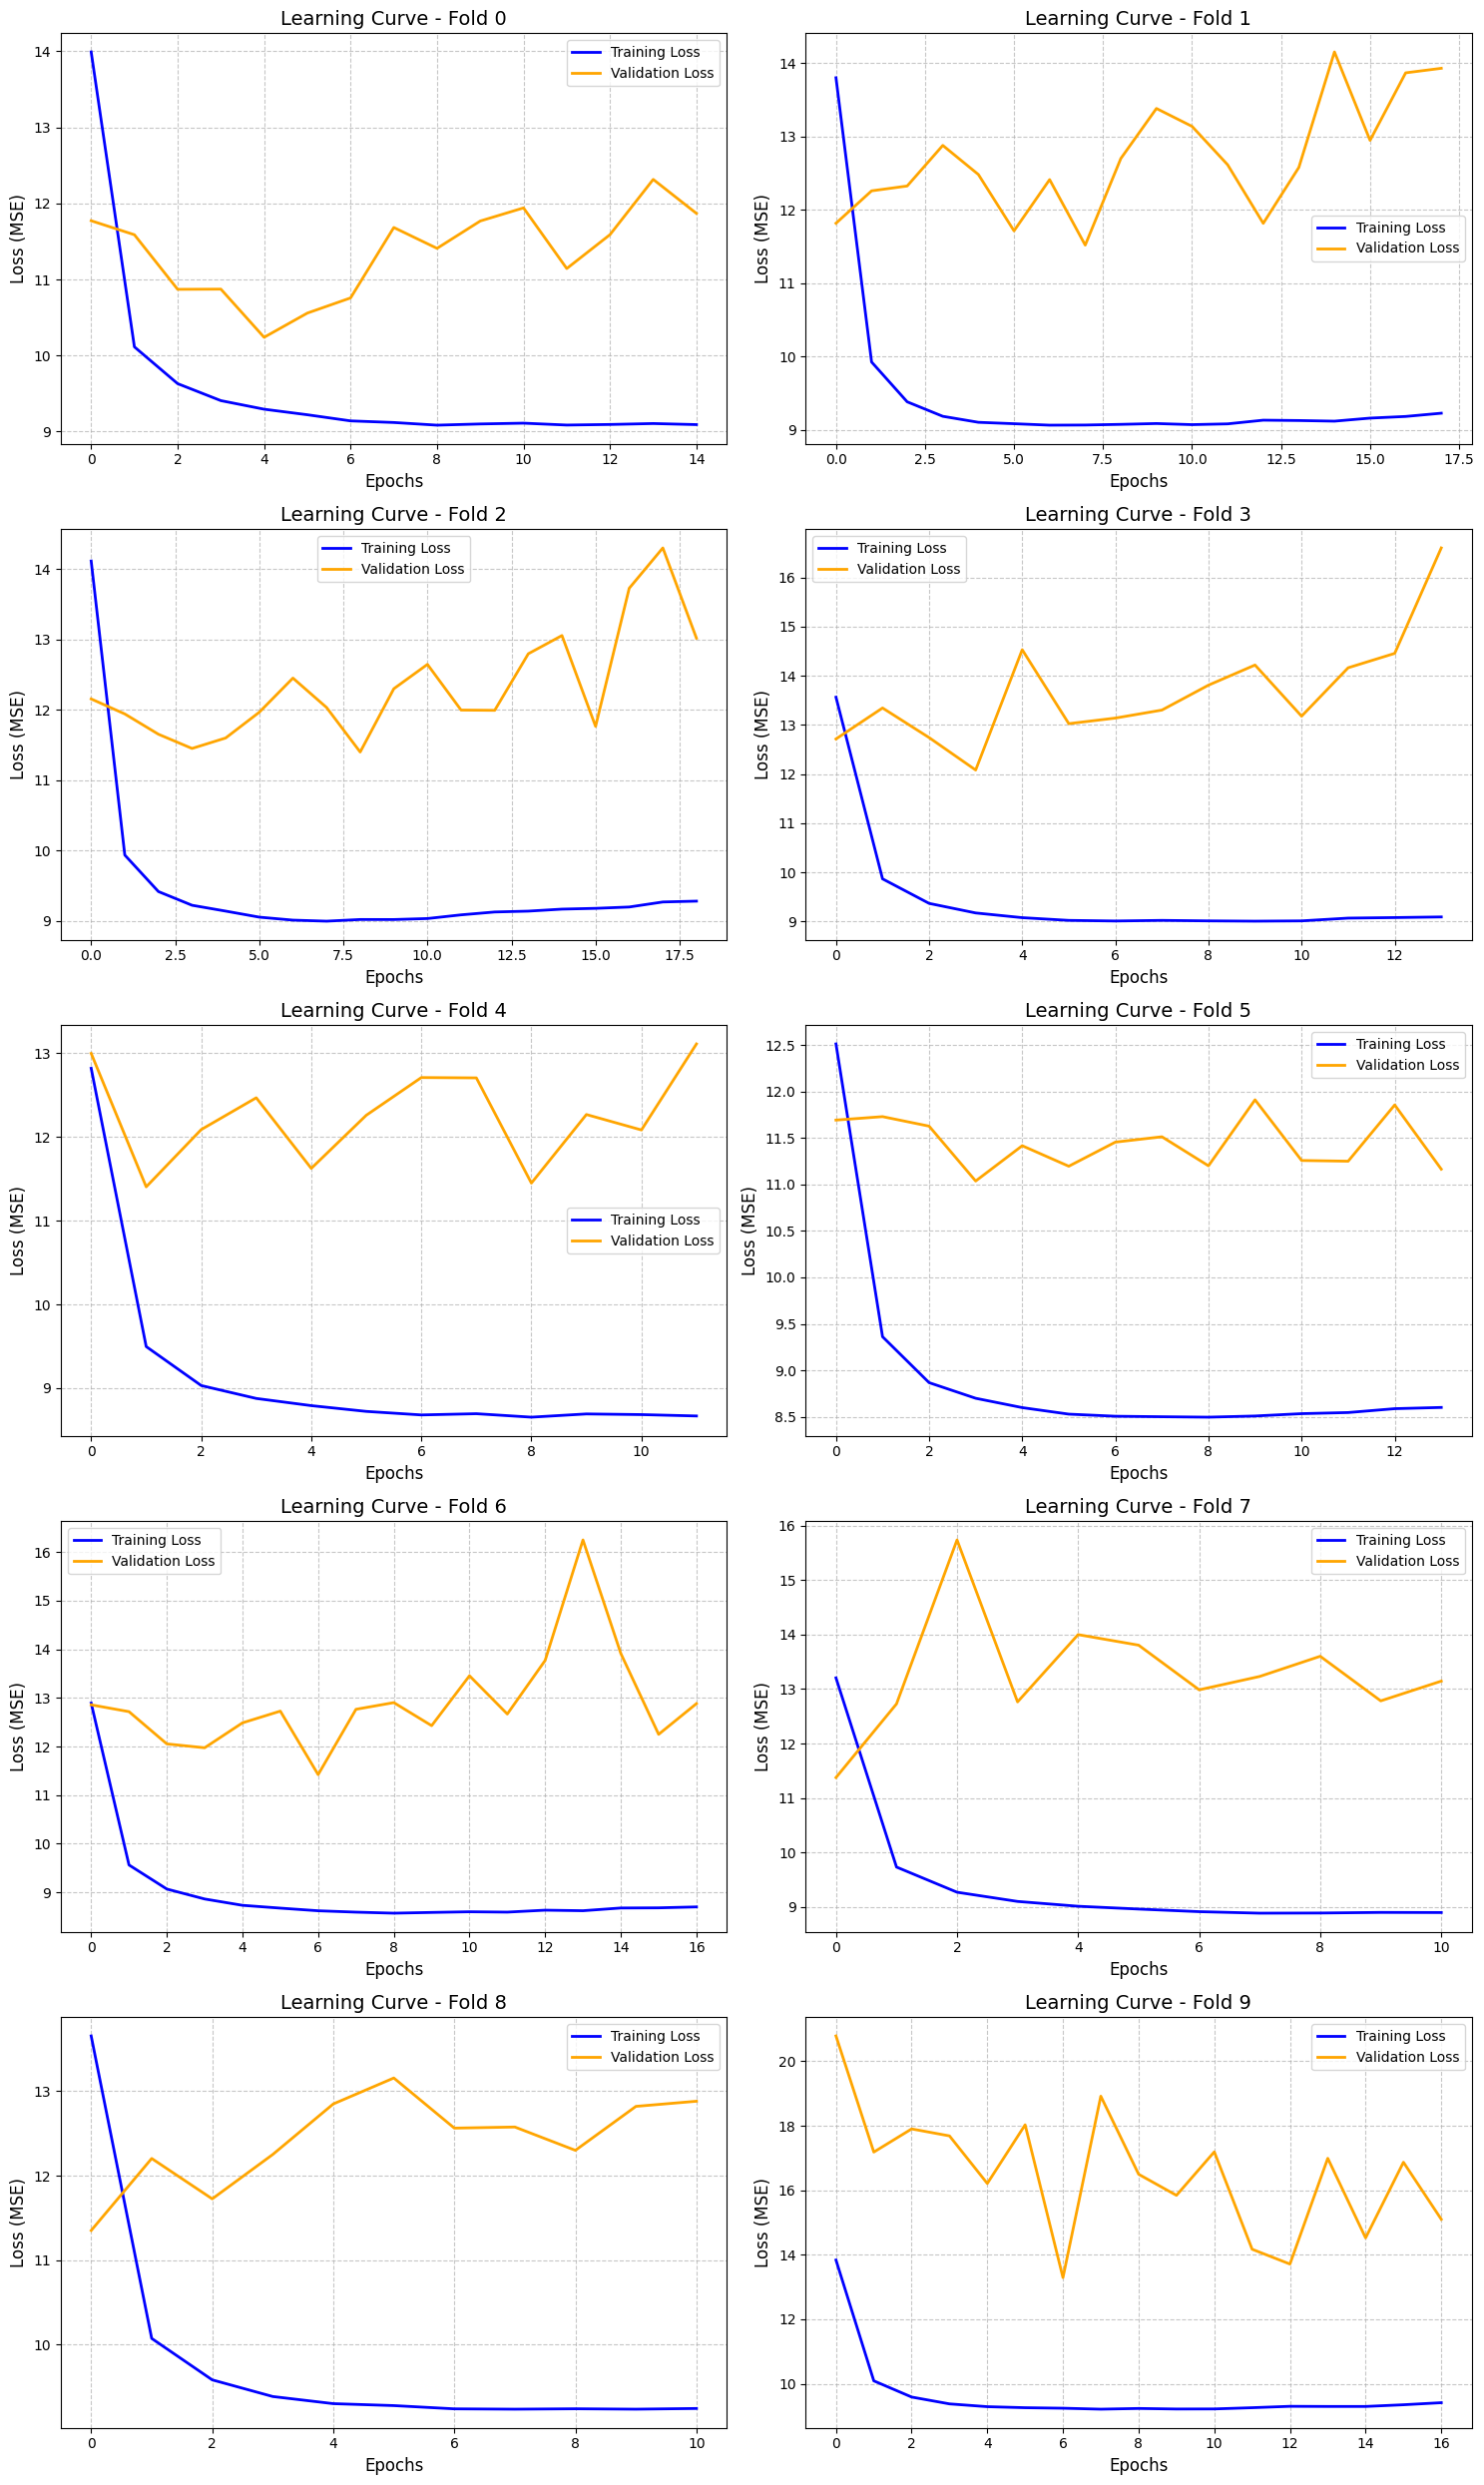

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_3_20260520_195537


In [12]:
k_fold_dict_3, save_dir_3 = pipeline(X_3, y_3, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_3")

### Comparison between corresponding tensorflow and pytorch outputs

=== Starting Experiment Comparison Analysis ===
Analisi exp tensorflow...
-> Rilevato formato TensorFlow. Estratti 10 valori MAE.
Analisi exp pytorch...
-> Rilevato formato PyTorch. Estratti 10 valori MAE.


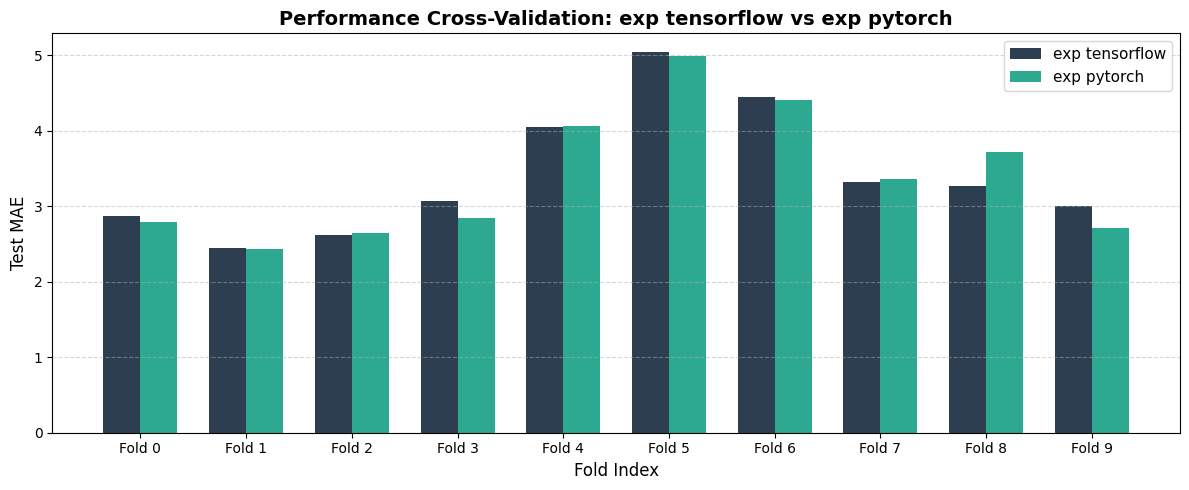

📊 Grafico salvato in: './comparison_exp_tensorflow_vs_exp_pytorch.png'
=== Processo di Confronto Completato ===


In [11]:
compare_experiments_pipeline(
    "2026_05_17_23_49_OUTPUTS_ORIGINAL_KERAS_ALL.txt", 
    "experiments/exp_3_20260520_195537/MAE_exp_3.txt", 
    exp1_label="exp tensorflow",
    exp2_label="exp pytorch",
    output_dir=".", 
    show_plots=True
)

## SHAP on Neural Network

### SHAP on experiment 2: Macro vs Micro Error Analysis

#### Data extraction using indices from previous pipeline k fold cross validation

In [12]:
import re
import numpy as np
import os
from shap_utils.explain_with_shap import *

log_file_path = "experiments/exp_2_20260521_203007/MAE_exp_2.txt" 

# Dizionario per immagazzinare gli indici ricostruiti
extracted_test_indices = {}
fold_counter = 0

print("🔍 Lettura del log e ricostruzione degli indici in corso...")

# 1. Lettura dal file txt
if os.path.exists(log_file_path):
    with open(log_file_path, 'r') as file:
        for line in file:
            # Isoliamo le righe relative al TEST set
            if line.startswith("TEST:"):
                # re.findall(r'\d+', line) estrae tutti i gruppi di numeri ignorando parentesi e puntini
                numbers = [int(n) for n in re.findall(r'\d+', line)]
                
                if len(numbers) >= 2:
                    start_idx = numbers[0]   # Es. Fold 1: 190585
                    end_idx = numbers[-1]    # Es. Fold 1: 381168
                    
                    # Genera l'array continuo: [190585, 190586, ..., 381168]
                    extracted_test_indices[fold_counter] = np.arange(start_idx, end_idx + 1)
                
                fold_counter += 1
else:
    raise FileNotFoundError(f"File non trovato al percorso: {log_file_path}")

# 2. Assegnazione basata sull'indice globale
total_samples = len(X)
all_indices = np.arange(total_samples)

# ==========================================
# ESTRAZIONE DATI - FOLD 1 (Fold Sano)
# ==========================================
# Il Test set è l'array appena ricostruito
test_idx_f1 = extracted_test_indices[1]
# Il Train set è tutto il resto (Indici globali - Indici di test)
train_idx_f1 = np.setdiff1d(all_indices, test_idx_f1) 

X_train_fold1 = X[train_idx_f1]
X_test_fold1  = X[test_idx_f1]

# ==========================================
# ESTRAZIONE DATI - FOLD 5 (Fold Anomalo)
# ==========================================
test_idx_f5 = extracted_test_indices[5]
train_idx_f5 = np.setdiff1d(all_indices, test_idx_f5)

X_train_fold5 = X[train_idx_f5]
X_test_fold5  = X[test_idx_f5]
# Estraiamo anche i target reali per calcolare l'errore effettivo sui grafici Waterfall
y_test_fold5  = y[test_idx_f5]

print("✅ Operazione completata con successo! I dati estratti sono:")
print(f"   🔹 FOLD 1 -> Train: {X_train_fold1.shape}, Test: {X_test_fold1.shape}")
print(f"   🔹 FOLD 5 -> Train: {X_train_fold5.shape}, Test: {X_test_fold5.shape}")

🔍 Lettura del log e ricostruzione degli indici in corso...
✅ Operazione completata con successo! I dati estratti sono:
   🔹 FOLD 1 -> Train: (1715257, 19), Test: (190584, 19)
   🔹 FOLD 5 -> Train: (1715257, 19), Test: (190584, 19)


In [13]:
# 0. Estrazione preliminare dei nomi delle feature (con Solar Flux incluso)
feature_names_2 = extract_feature_names(dataset_path="Data/MARSIS_historical_dataset.csv", keep_flux=True)
input_dim_2 = len(feature_names_2)

#### Fold 1


--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_1.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.


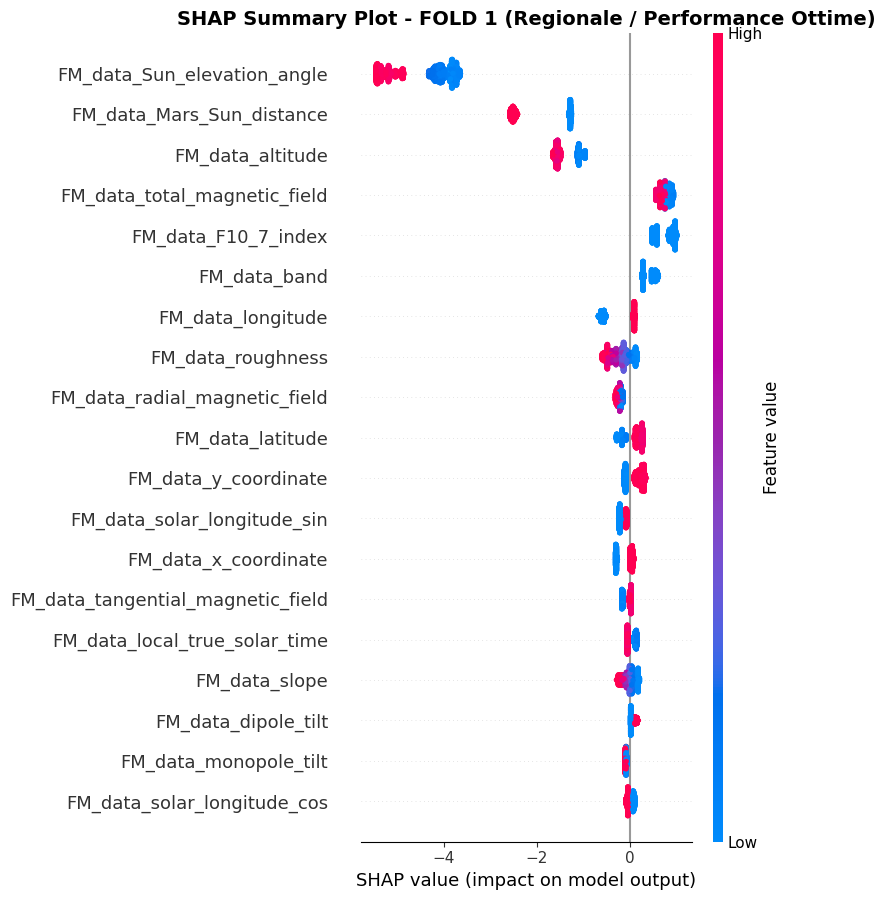

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import shap

# =====================================================================
# STEP 1: MACRO ANALYSIS - REGION COMPARISON (FOLD 1 vs FOLD 5)
# =====================================================================

print("\n--- 1A. Esecuzione SHAP su FOLD 1 (Zona Regolare - Performance Buone) ---")
model_fold1 = NeurNet(input_dim=input_dim_2)
weights_f1 = "experiments/exp_2_20260521_203007/model_exp_2_1.pth"
scaler_f1 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_1.save"

shap_values_f1, X_test_scaled_f1, explainer_f1 = explain_with_shap(
    model=model_fold1,
    weights_path=weights_f1,
    scaler_path=scaler_f1,
    X_background_raw=X_train_fold1,  # Matrice grezza di train del Fold 1
    X_test_raw=X_test_fold1,          # Matrice grezza di test del Fold 1
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

# Renderizzazione del Summary Plot del Fold Sano
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_f1, X_test_scaled_f1, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 1 (Regionale / Performance Ottime)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### Fold 5


--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---

=== STARTING SHAP PIPELINE ===
Model: experiments/exp_2_20260521_203007/model_exp_2_5.pth | Scaler: experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save
Forced device for SHAP stability: cpu
SHAP calculation (Background: 500 samples, Test: 2000 samples)...
Generating plot...
SHAP calculation completed.


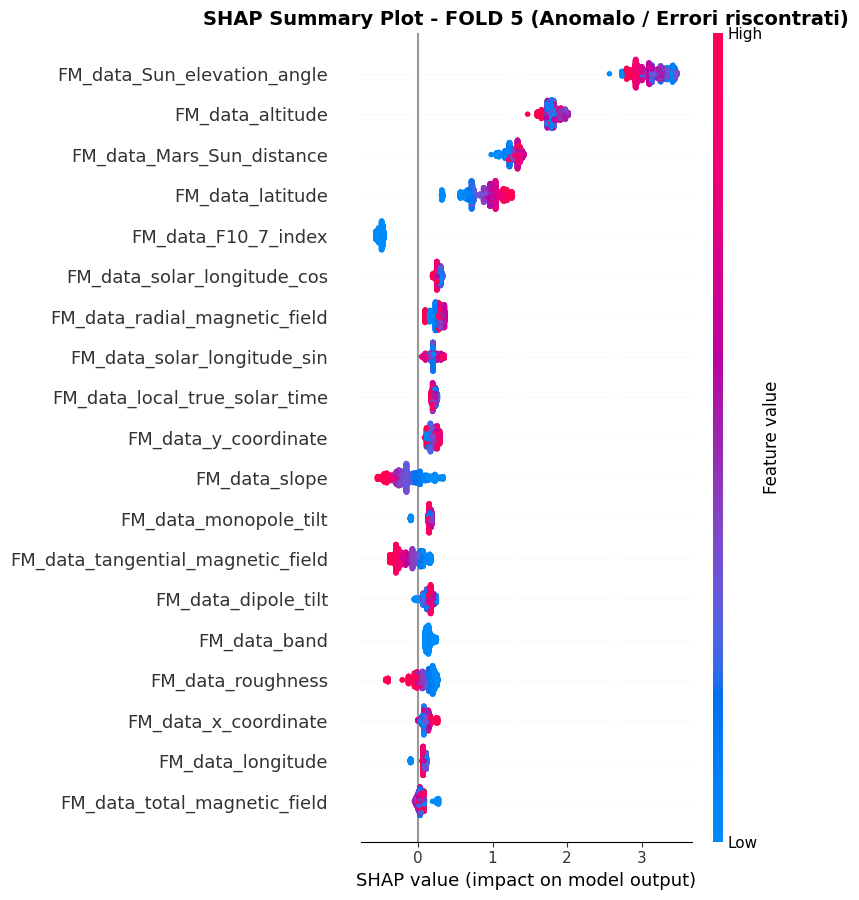

In [15]:
print("\n--- 1B. Esecuzione SHAP su FOLD 5 (Zona Problematica - Errore Elevato) ---")
model_fold5 = NeurNet(input_dim=input_dim_2)
weights_f5 = "experiments/exp_2_20260521_203007/model_exp_2_5.pth"
scaler_f5 = "experiments/exp_2_20260521_203007/scaler_chrono_exp_2_5.save"

shap_values_f5, X_test_scaled_f5, explainer_f5 = explain_with_shap(
    model=model_fold5,
    weights_path=weights_f5,
    scaler_path=scaler_f5,
    X_background_raw=X_train_fold5,  # Matrice grezza di train del Fold 5
    X_test_raw=X_test_fold5,          # Matrice grezza di test del Fold 5
    feature_names=feature_names_2,
    bg_limit=500,
    test_limit=2000
)

# Renderizzazione del Summary Plot del Fold Anomalo
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_f5, X_test_scaled_f5, feature_names=feature_names_2, show=False)
plt.title("SHAP Summary Plot - FOLD 5 (Anomalo / Errori riscontrati)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Micro analysis


--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---
Indici dei campioni più problematici nel Fold 5: [1663 1665 1664]
Errori assoluti corrispondenti: [13.4509449  13.34175682 13.29695511]

Generazione Waterfall Plot per il campione ad alto errore (Indice: 1663)...


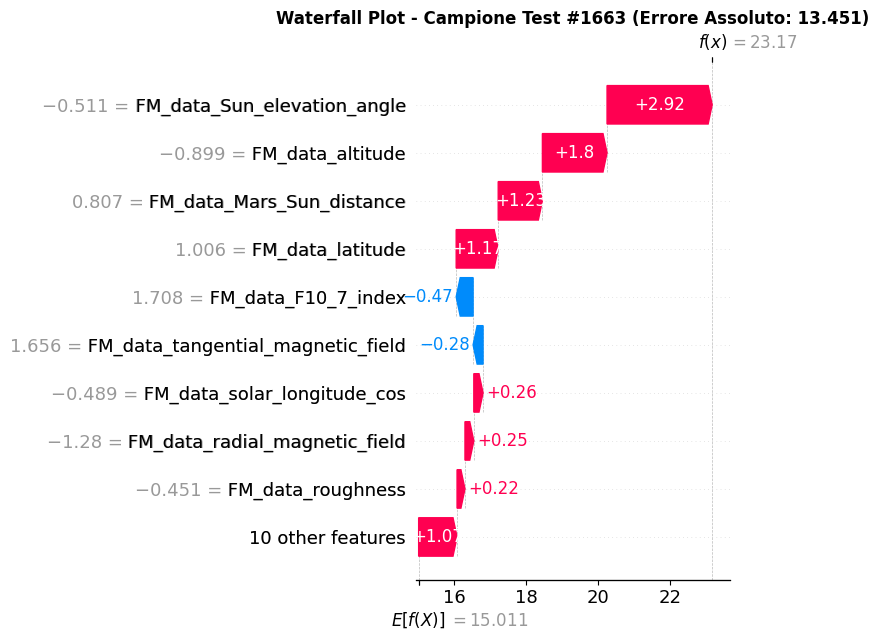


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1665)...


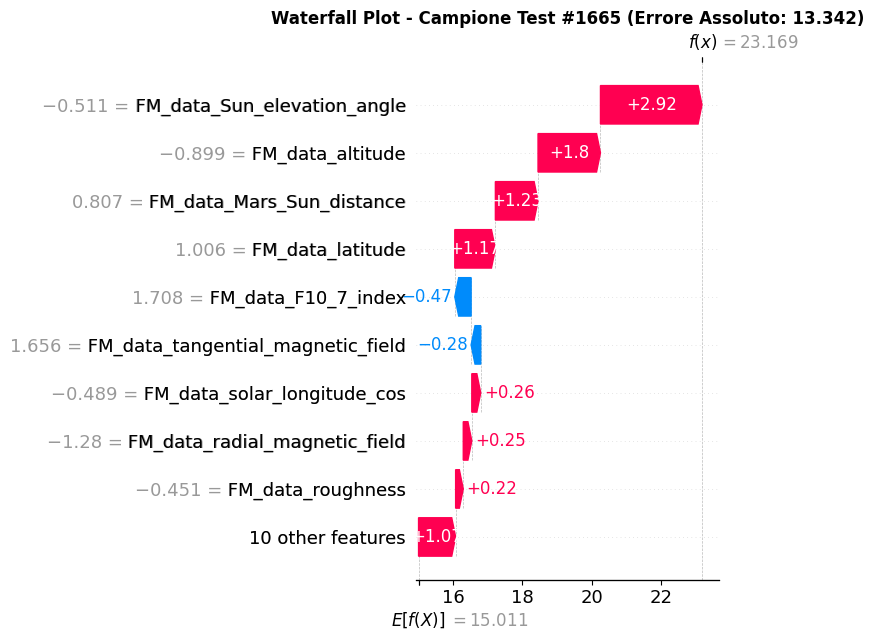


Generazione Waterfall Plot per il campione ad alto errore (Indice: 1664)...


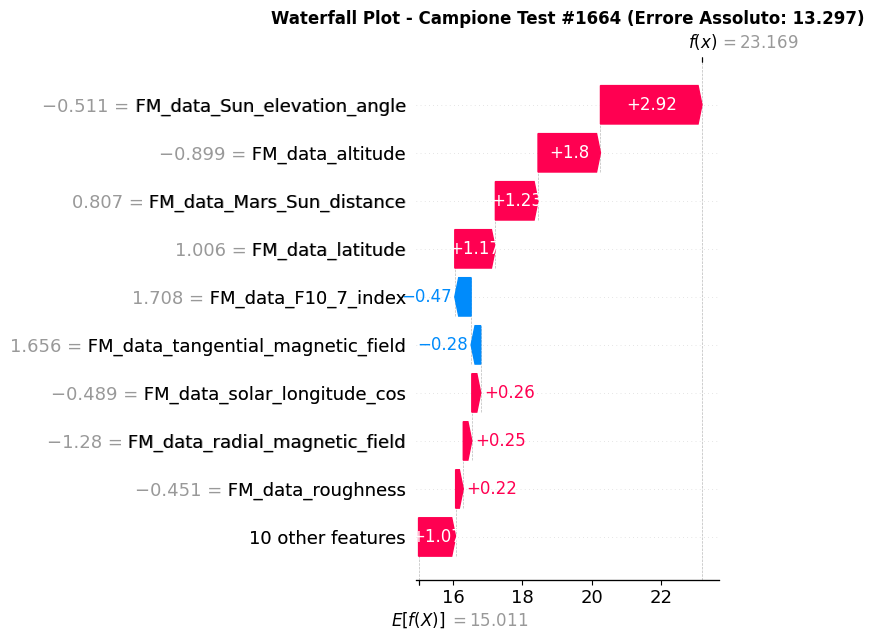

In [16]:
# =====================================================================
# STEP 2: ANALISI MICROSCOPICA - ISOLAMENTO ANOMALIE & WATERFALL PLOT
# =====================================================================
print("\n--- 2. Estrazione e Analisi dei peggiori campioni del Fold 5 ---")

# Generazione delle predizioni del modello per calcolare l'errore reale residuo
model_fold5.to("cpu")
model_fold5.eval()
with torch.no_grad():
    # Convertiamo i dati di test già normalizzati in tensore pytorch
    tensor_test_f5 = torch.tensor(X_test_scaled_f5, dtype=torch.float32)
    # Calcolo output della rete e conversione in vettore numpy flat
    y_pred_f5 = model_fold5(tensor_test_f5).cpu().numpy().flatten()

# Calcolo del residuo assoluto su scala reale: Errore = |Y_predicton - Y_true|
# Assicurati che y_test_fold5 sia un array monodimensionale di numpy
limit = len(y_pred_f5)
absolute_errors = np.abs(y_pred_f5 - y_test_fold5[:limit].flatten())

# Estrazione degli indici dei 3 campioni con l'errore più alto (ordinamento crescente, prendi gli ultimi 3)
worst_samples_indices = np.argsort(absolute_errors)[-3:][::-1]

print(f"Indici dei campioni più problematici nel Fold 5: {worst_samples_indices}")
print(f"Errori assoluti corrispondenti: {absolute_errors[worst_samples_indices]}")

# Estrazione del valore atteso (E[f(x)]) di base dal DeepExplainer
base_value = explainer_f5.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[0]

# Generazione dei Waterfall Plot locali per ogni anomalia isolata
for idx in worst_samples_indices:
    print(f"\nGenerazione Waterfall Plot per il campione ad alto errore (Indice: {idx})...")
    
    # Chirurgia SHAP: DeepExplainer non supporta nativamente i grafici locali a cascata. 
    # Dobbiamo impacchettare i vettori dentro un oggetto contenitore shap.Explanation.
    explanation_object = shap.Explanation(
        values=shap_values_f5[idx], 
        base_values=base_value, 
        data=X_test_scaled_f5[idx], 
        feature_names=feature_names_2
    )
    
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(explanation_object, show=False)
    plt.title(f"Waterfall Plot - Campione Test #{idx} (Errore Assoluto: {absolute_errors[idx]:.3f})", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()